<a href="https://colab.research.google.com/github/cristianenunes2401-byte/Data_Analytics_Tech_Challenge_FIAP/blob/main/notebook_modelagem_Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import arquivos e bibliotecas**

In [8]:
#Manipulação dos dados
import pandas as pd
import numpy as np

#Visualização dos dados
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

In [9]:
df_cli = pd.read_csv('olist_customers_dataset.csv') #tb de clientes
df_geol = pd.read_csv('olist_geolocation_dataset.csv') #tb de localização geografica
df_items = pd.read_csv('olist_order_items_dataset.csv') #tb dos itens vendidos em cada pedido
df_payments = pd.read_csv('olist_order_payments_dataset.csv') #tb de pagamentos
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv') #tb de avaliação de clientes
df_orders = pd.read_csv('olist_orders_dataset.csv') #tb principal dos pedidos
df_products = pd.read_csv('olist_products_dataset.csv') #tb de produtos
df_sellers = pd.read_csv('olist_sellers_dataset.csv') #tb de vendedores
df_translation = pd.read_csv('product_category_name_translation.csv') #tb de tradução categórica

#**Cruzamentos e geração da base limpa e unificada**

In [10]:
# ============================
# ETAPA 1: Unir Pedidos com Clientes
df = pd.merge(df_orders, df_cli, on='customer_id', how='left')

# ETAPA 2: Unir com Itens do Pedido
df = pd.merge(df, df_items, on='order_id', how='left')

# ETAPA 3: Unir com Produtos categorias
df = pd.merge(df, df_products, on='product_id', how='left')

# ETAPA 4: Unir com Pagamentos
df = pd.merge(df, df_payments, on='order_id', how='left')

# ETAPA 5: Unir com Vendedores
df = pd.merge(df, df_sellers, on='seller_id', how='left')

# ETAPA 6: Unir com Reviews
df = pd.merge(df, df_reviews, on='order_id', how='left')

# ETAPA 7: Traduzir nomes de categorias
df = pd.merge(df, df_translation, on='product_category_name', how='left')

# ============================
# TRATAMENTO DE DATAS
date_columns = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# ============================
# FILTRO: Apenas pedidos entregues
df_final = df[df['order_status'] == 'delivered'].copy()

# ============================
# INFO FINAL
print("Base final consolidada:")
print(df_final.shape)
df_final.info()

Base final consolidada:
(115723, 40)
<class 'pandas.core.frame.DataFrame'>
Index: 115723 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115723 non-null  object        
 1   customer_id                    115723 non-null  object        
 2   order_status                   115723 non-null  object        
 3   order_purchase_timestamp       115723 non-null  datetime64[ns]
 4   order_approved_at              115708 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115721 non-null  datetime64[ns]
 6   order_delivered_customer_date  115715 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115723 non-null  datetime64[ns]
 8   customer_unique_id             115723 non-null  object        
 9   customer_zip_code_prefix       115723 non-null  int64         
 10  customer_city                  11572

#**Agrupamento para output da matriz de análise**

In [30]:
import pandas as pd

# Criar coluna de receita total (preço + frete)
df['receita_total'] = df['price'] + df['freight_value']

# Criar coluna de ano-mês em dois formatos
df['anomes_num'] = df['order_purchase_timestamp'].dt.strftime('%Y%m')   # formato numérico (ex: 202602)
df['anomes_date'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()  # formato datetime (primeiro dia do mês)

# Agrupar por ano-mês (numérico + date) e outras dimensões
df_grouped = (
    df.groupby(['anomes_num', 'anomes_date', 'product_category_name_english', 'customer_state', 'payment_type'])
    .agg({
        'order_id': 'nunique',          # número de pedidos únicos
        'customer_id': 'nunique',       # número de clientes únicos
        'receita_total': 'sum',         # receita total
        'freight_value': 'mean',        # frete médio
        'review_score': 'mean'          # nota média
    })
    .reset_index()
)

# Calcular ticket médio corretamente: receita total / número de pedidos
df_grouped['ticket_medio'] = df_grouped['receita_total'] / df_grouped['order_id']

# Renomear colunas para clareza
df_grouped.rename(columns={
    'order_id': 'num_pedidos',
    'customer_id': 'num_clientes',
    'freight_value': 'frete_medio',
    'review_score': 'nota_media'
}, inplace=True)

# Visualizar resultado
print(df_grouped.head())

# Salvar a base agrupada para análise externa
df_grouped.to_excel('base_agrupada.xlsx', index=False)


  anomes_num anomes_date product_category_name_english customer_state  \
0     201609  2016-09-01               furniture_decor             RR   
1     201609  2016-09-01                     telephony             RS   
2     201610  2016-10-01              air_conditioning             MG   
3     201610  2016-10-01              air_conditioning             RS   
4     201610  2016-10-01              air_conditioning             SC   

  payment_type  num_pedidos  num_clientes  receita_total  frete_medio  \
0  credit_card            1             1         136.23        31.67   
1  credit_card            1             1          75.06        15.56   
2  credit_card            1             1         319.00        19.01   
3  credit_card            1             1         401.30        21.75   
4  credit_card            1             1         676.92        19.33   

   nota_media  ticket_medio  
0         1.0        136.23  
1         1.0         75.06  
2         1.0        319.00  
3 

#**Olist - Desempenho Comercial**

# **1. Receita Total vs. Ticket Médio**

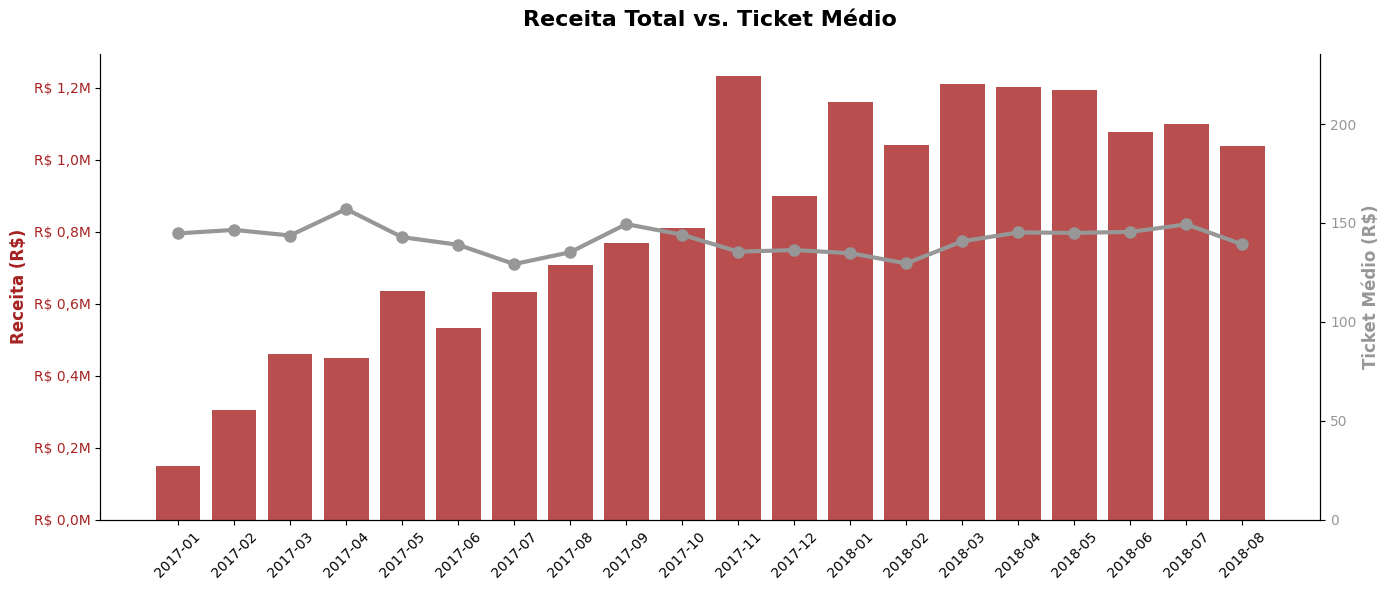

In [29]:
# Receita Total
df['Receita_Total'] = df['price'] + df['freight_value']

# Anomes
df['Ano_Mes'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupando os dados por mês
df_view_receita = df.groupby('Ano_Mes').agg(
    Pedidos=('order_id', 'nunique'), # Contagem de pedidos únicos
    Receita=('Receita_Total', 'sum'),
    Ticket_Medio=('Receita_Total', 'mean')
).reset_index()

# delimitando perimetro
df_view_receita = df_view_receita[(df_view_receita['Ano_Mes'] >= '2017-01') & (df_view_receita['Ano_Mes'] <= '2018-08')]

fig, ax1 = plt.subplots(figsize=(14, 6), facecolor='white')

# Eixo 1: Receita Total
ax1.bar(df_view_receita['Ano_Mes'], df_view_receita['Receita'], color='#A62222', alpha=0.8, label='Receita Total')
ax1.set_ylabel('Receita (R$)', color='#A62222', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#A62222')
plt.xticks(rotation=45)

# Formatando o eixo Y da receita para M (Milhões)
formatter = ticker.FuncFormatter(lambda x, p: f'R$ {x/1000000:.1f}M'.replace('.', ','))
ax1.yaxis.set_major_formatter(formatter)

# Eixo 2: Ticket Médio
ax2 = ax1.twinx()
ax2.plot(df_view_receita['Ano_Mes'], df_view_receita['Ticket_Medio'], color='#979797', marker='o', linewidth=3, markersize=8, label='Ticket Médio')
ax2.set_ylabel('Ticket Médio (R$)', color='#979797', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#979797')
ax2.set_ylim(0, df_view_receita['Ticket_Medio'].max() * 1.5)

# Formatação
ax1.set_title('Receita Total vs. Ticket Médio', fontweight='bold', fontsize=16, pad=20)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


Entre os dois primeiros quadrimestres de cada ano, a empresa cresceu 135% em receita, o que indica uma forte expansão de volume de vendas e maior penetração no mercado. Esse salto mostra que a estratégia de aquisição de novos clientes e ampliação de pedidos está funcionando.

Por outro lado, o ticket médio se manteve estável, o que revela que o aumento da receita não veio de um maior gasto por cliente, mas sim de mais transações. Em outras palavras, o crescimento está sendo impulsionado por quantidade, não por maior gasto por cliente.

#**2. Participação na Receita por UF**

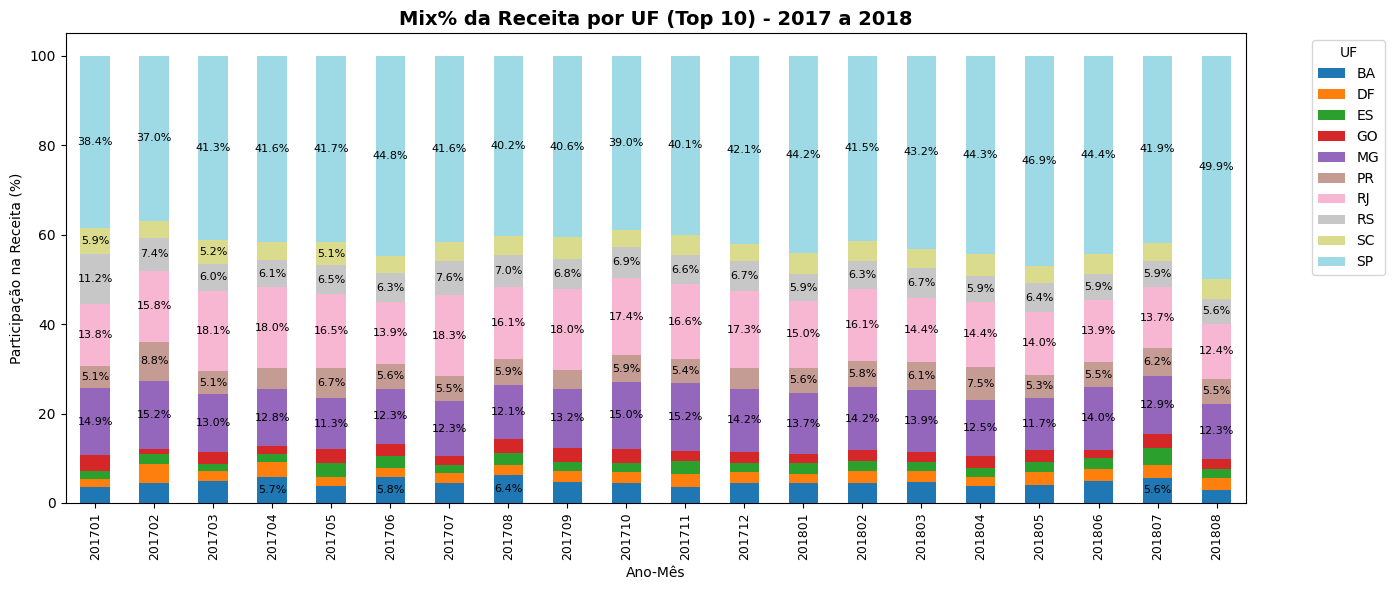

In [33]:


# Filtrar intervalo de meses
df_plot = df_grouped[(df_grouped['anomes_num'] >= '201701') & (df_grouped['anomes_num'] <= '201808')]

# Agrupar receita por mês e UF
receita_uf = df_plot.groupby(['anomes_num','customer_state'])['receita_total'].sum().reset_index()

# Identificar os 10 estados com maior receita total no período
top10_uf = receita_uf.groupby('customer_state')['receita_total'].sum().nlargest(10).index

# Filtrar apenas os top 10
receita_top10 = receita_uf[receita_uf['customer_state'].isin(top10_uf)]

# Pivotar para ter meses como linhas e estados como colunas
pivot_uf = receita_top10.pivot(index='anomes_num', columns='customer_state', values='receita_total').fillna(0)

# Converter para mix% (base 100 por mês)
pivot_uf_pct = pivot_uf.div(pivot_uf.sum(axis=1), axis=0) * 100

# Plotar gráfico de barras empilhadas
ax = pivot_uf_pct.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.title('Mix% da Receita por UF (Top 10) - 2017 a 2018', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês')
plt.ylabel('Participação na Receita (%)')
plt.xticks(rotation=90, fontsize=9)
plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar rótulos de dados (mix%)
for i, row in enumerate(pivot_uf_pct.values):
    cum_height = 0
    for j, val in enumerate(row):
        if val > 5:  # só mostrar rótulo se participação >5% para não poluir
            plt.text(i, cum_height + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=8)
        cum_height += val

plt.tight_layout()
plt.show()




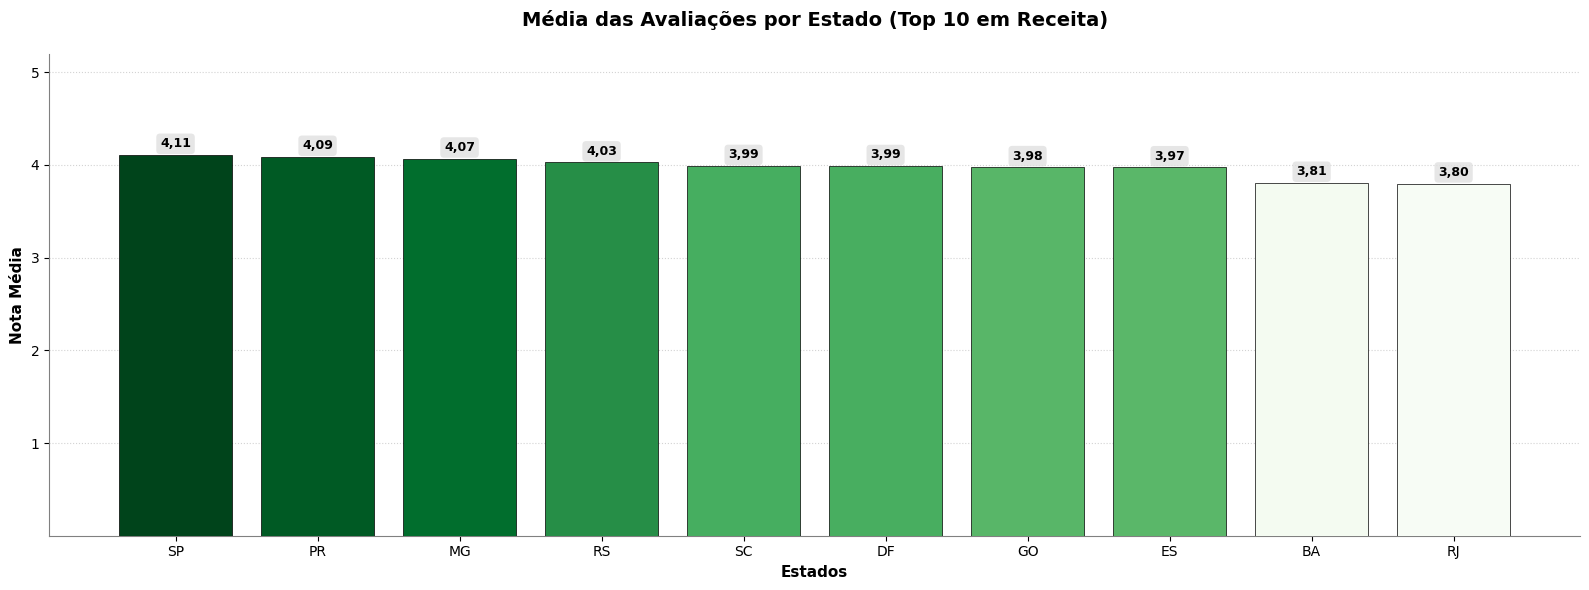

In [49]:

# Receita total
df['Receita_Total'] = df['price'] + df['freight_value']

# Top 10 UFs por receita
top10_uf = (
    df.groupby('customer_state')['Receita_Total']
    .sum()
    .reset_index()
    .sort_values('Receita_Total', ascending=False)
    .head(10)['customer_state']
)

# Média de review_score por estado (somente top 10)
df_estado = (
    df[df['customer_state'].isin(top10_uf)]
    .groupby('customer_state')['review_score']
    .mean()
    .reset_index()
    .sort_values('review_score', ascending=False)
)

# Figura
fig, ax = plt.subplots(figsize=(16, 6), facecolor='white')

# Gradiente de cores (verde escuro → verde claro)
norm = mcolors.Normalize(vmin=df_estado['review_score'].min(), vmax=df_estado['review_score'].max())
cmap = plt.cm.Greens
cores = [cmap(norm(value)) for value in df_estado['review_score']]

# Barras
barras = ax.bar(
    df_estado['customer_state'],
    df_estado['review_score'],
    color=cores,
    edgecolor='black',
    linewidth=0.5,
    zorder=3
)

# Formatação
ax.set_ylim(0, 5.2)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylabel('Nota Média', fontsize=11, fontweight='bold')
ax.set_xlabel('Estados', fontsize=11, fontweight='bold')
ax.set_title('Média das Avaliações por Estado (Top 10 em Receita)', fontweight='bold', fontsize=14, pad=20)

# Linhas de grade
ax.yaxis.grid(True, linestyle='dotted', color='lightgray', zorder=0)

# Remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')

# Rótulos de dados
for barra in barras:
    altura = barra.get_height()
    texto_label = f"{altura:.2f}".replace('.', ',')
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.05,
        texto_label,
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9,
        bbox=dict(facecolor='#E0E0E0', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8)
    )

plt.tight_layout()
plt.show()




São Paulo concentra entre 37% e 50% da receita total, mantendo liderança absoluta ao longo de todo o período. Essa estabilidade indica uma dependência estrutural: o crescimento da operação está fortemente vinculado ao desempenho paulista.
Embora SP seja um polo natural de consumo e logística, essa concentração representa risco de saturação e baixa diversificação geográfica. Se houver qualquer oscilação econômica ou competitiva local, o impacto na receita total será imediato.

Minas Gerais (4,07), Paraná (4,09) e Rio de Janeiro (3,80) têm notas médias de satisfação elevadas, próximas ou acima da média geral.
Esses estados também aparecem com participação relevante no mix de receita, mas ainda sem crescimento expressivo, o que significa que há espaço para expansão sem comprometer a experiência do cliente.

# **3. Top 10 Produtos por Número de Pedidos**

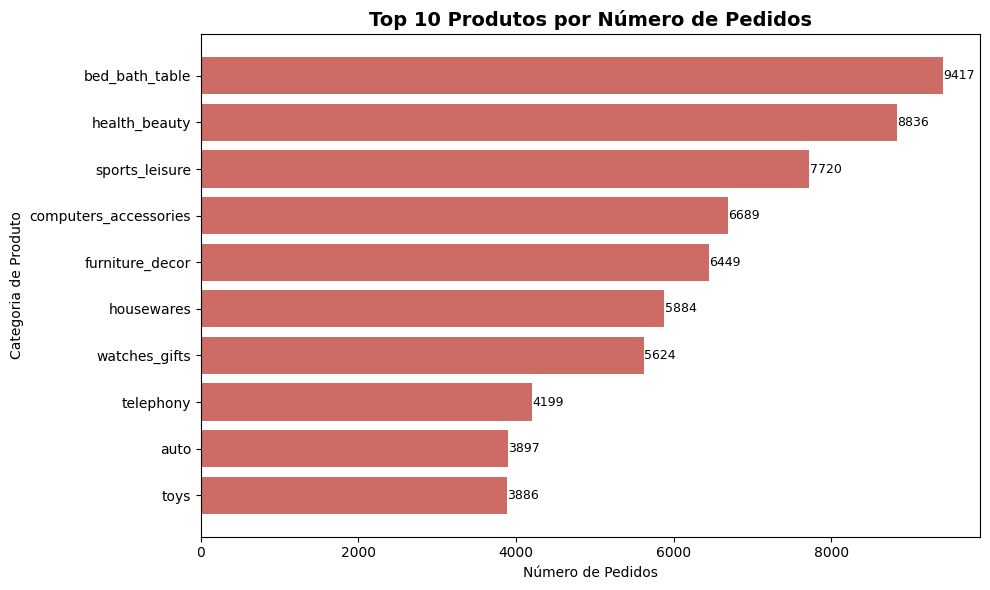

In [36]:


# Criar coluna de Receita Total
df['Receita_Total'] = df['price'] + df['freight_value']

# Agrupar por produto
produtos_perf = df.groupby('product_category_name_english').agg(
    Pedidos=('order_id','nunique'),
    Receita=('Receita_Total','sum'),
    Ticket_Medio=('Receita_Total','mean')
).reset_index()

# Selecionar Top 10 produtos por número de pedidos
top_produtos_pedidos = produtos_perf.sort_values(by='Pedidos', ascending=False).head(10)

# Gráfico de barras horizontais
plt.figure(figsize=(10,6))
plt.barh(top_produtos_pedidos['product_category_name_english'],
         top_produtos_pedidos['Pedidos'],
         color='#CD6C65')

# Adicionar rótulos de dados
for i, v in enumerate(top_produtos_pedidos['Pedidos']):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)

plt.title('Top 10 Produtos por Número de Pedidos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Pedidos')
plt.ylabel('Categoria de Produto')
plt.gca().invert_yaxis()  # Inverter eixo Y para mostrar o maior no topo
plt.tight_layout()
plt.show()



Categorias como bed_bath_table, health_beauty e sports_leisure lideram em volume de pedidos, indicando forte apelo de consumo e recorrência. Esses produtos são os motores de volume, mas nem sempre os de maior ticket. Há espaço para explorar produtos complementares e premium.

# **4. Evolução da Retenção de Clientes por Mês**

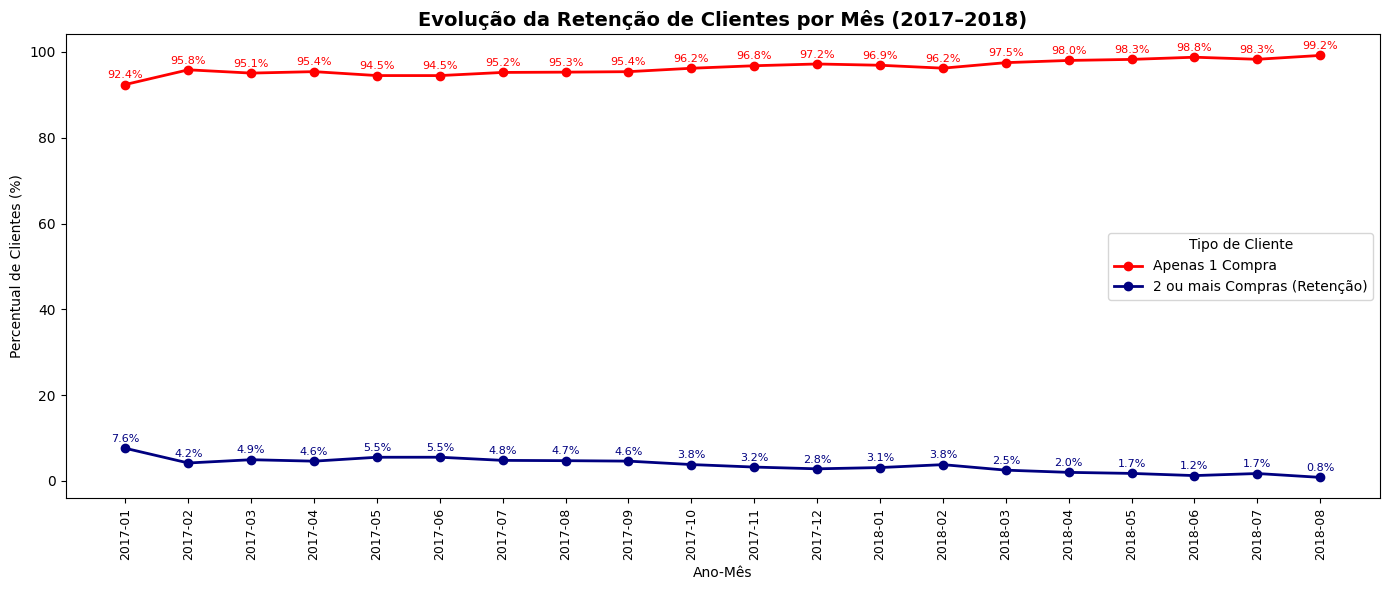

In [39]:


# Receita Total
df['Receita_Total'] = df['price'] + df['freight_value']

# Criar coluna Ano-Mês
df['Ano_Mes'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Contar quantos pedidos cada cliente fez no total
df_clientes = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_clientes.columns = ['customer_unique_id', 'Qtd_Compras']

# Classificar clientes
df_clientes['Tipo_Cliente'] = np.where(df_clientes['Qtd_Compras'] == 1,
                                       'Apenas 1 Compra',
                                       '2 ou mais Compras (Retenção)')

# Mês da primeira compra
df_first_purchase = df.groupby('customer_unique_id')['Ano_Mes'].min().reset_index()
df_first_purchase.columns = ['customer_unique_id','Mes_Primeira_Compra']

df_clientes = df_clientes.merge(df_first_purchase, on='customer_unique_id')

# Distribuição por mês
retencao_mes = df_clientes.groupby(['Mes_Primeira_Compra','Tipo_Cliente']).size().reset_index(name='Qtd')
retencao_mes_total = retencao_mes.groupby('Mes_Primeira_Compra')['Qtd'].sum().reset_index(name='Total')
retencao_mes = retencao_mes.merge(retencao_mes_total, on='Mes_Primeira_Compra')
retencao_mes['Percentual'] = (retencao_mes['Qtd'] / retencao_mes['Total']) * 100

# Pivotar para gráfico
pivot_retencao = retencao_mes.pivot(index='Mes_Primeira_Compra', columns='Tipo_Cliente', values='Percentual').fillna(0)

# Filtrar período
pivot_retencao = pivot_retencao[(pivot_retencao.index >= '2017-01') & (pivot_retencao.index <= '2018-08')]

# Plotar gráfico de linhas
plt.figure(figsize=(14,6))

# Linha vermelha - Compra única
plt.plot(pivot_retencao.index, pivot_retencao['Apenas 1 Compra'],
         color='red', marker='o', linewidth=2, label='Apenas 1 Compra')

# Linha azul marinho - 2 ou mais compras
plt.plot(pivot_retencao.index, pivot_retencao['2 ou mais Compras (Retenção)'],
         color='navy', marker='o', linewidth=2, label='2 ou mais Compras (Retenção)')

# Adicionar rótulos de dados (%)
for x, y in zip(pivot_retencao.index, pivot_retencao['Apenas 1 Compra']):
    plt.text(x, y+1, f'{y:.1f}%', ha='center', va='bottom', fontsize=8, color='red')

for x, y in zip(pivot_retencao.index, pivot_retencao['2 ou mais Compras (Retenção)']):
    plt.text(x, y+1, f'{y:.1f}%', ha='center', va='bottom', fontsize=8, color='navy')

# Formatação
plt.title('Evolução da Retenção de Clientes por Mês (2017–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês')
plt.ylabel('Percentual de Clientes (%)')
plt.xticks(rotation=90, fontsize=9)
plt.legend(title='Tipo de Cliente')
plt.tight_layout()
plt.show()



A taxa de recompra é muito baixa (2–7%), com tendência de queda ao longo de 2018. A maioria dos clientes compra apenas uma vez. O modelo atual é fortemente baseado em aquisição, não em retenção. Há perda de valor de ciclo de vida do cliente.

O retrato que os dados revelam é contundente: crescemos em escala, mas não em valor. A receita sobe, puxada pelo volume de pedidos, mas o ticket médio permanece estável e a retenção é mínima, apenas 3% dos clientes voltam a comprar. Isso significa que estamos investindo pesado em aquisição sem transformar esse esforço em relacionamento duradouro.

A concentração em São Paulo, responsável por quase metade da receita, mostra dependência de um único mercado. Estados como MG, PR e RJ aparecem com potencial, mas ainda pouco explorados. Os produtos top performers sustentam o volume, mas não necessariamente a margem, e a satisfação média não se traduz em fidelização.

A recomendação final estratégica passa por três pilares:

Regionalização inteligente: expandir hubs logísticos fora do eixo SP–RJ, especialmente no Sul e Nordeste, para reduzir frete e tempo de entrega.

Foco em experiência e recompra: ranquear sellers e destacar apenas os com alta avaliação e entrega rápida; implementar programas de fidelidade e campanhas de reativação.

Gestão de margem e ticket: usar inteligência de dados para sugerir combos e upsell, elevando o valor médio por pedido sem aumentar o custo de aquisição.